# Partie I – MLP et ingénierie PyTorch

### Préparation des données

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import copy

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# 1. Chargement et nettoyage (dataset sans valeurs manquantes)
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Séparation : Apprentissage (70%), Validation (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# 3. Normalisation (fit uniquement sur le train pour éviter le data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 4. Conversion en Tenseurs
def to_tensor(X_arr, y_arr):
    return torch.tensor(X_arr, dtype=torch.float32), torch.tensor(y_arr, dtype=torch.float32).view(-1, 1)

X_train_t, y_train_t = to_tensor(X_train_scaled, y_train)
X_val_t, y_val_t = to_tensor(X_val_scaled, y_val)
X_test_t, y_test_t = to_tensor(X_test_scaled, y_test)

# 5. DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

### Implémentation des deux versions d'un MLP

In [2]:
input_dim = X_train.shape[1]

# Version 1 : nn.Sequential
mlp_sequential = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

# Version 2 : Classe personnalisée
class CustomMLP(nn.Module):
    def __init__(self, input_size):
        super(CustomMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(32, 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.out(x)
        return x

model = CustomMLP(input_dim)

### Inspection et Initialisation

In [3]:
# Inspection avec named_parameters()
print("--- Inspection des Paramètres ---")
for name, param in model.named_parameters():
    print(f"Couche: {name} | Taille: {list(param.size())} | Gradient requis: {param.requires_grad}")

# Inspection du state_dict()
print("\n--- Clés du state_dict ---")
print(model.state_dict().keys())

# Fonction pour tester 3 stratégies d'initialisation
def apply_initialization(model, strategy):
    for name, param in model.named_parameters():
        if 'weight' in name:
            if strategy == 'gaussienne':
                nn.init.normal_(param, mean=0.0, std=0.01)
            elif strategy == 'constante':
                nn.init.constant_(param, 0.1)
            elif strategy == 'xavier':
                nn.init.xavier_uniform_(param)
        elif 'bias' in name:
            nn.init.constant_(param, 0)
    print(f"Initialisation {strategy} appliquée.")

# Test des 3 stratégies
apply_initialization(model, 'gaussienne')
apply_initialization(model, 'constante')
apply_initialization(model, 'xavier')

--- Inspection des Paramètres ---
Couche: fc1.weight | Taille: [64, 30] | Gradient requis: True
Couche: fc1.bias | Taille: [64] | Gradient requis: True
Couche: fc2.weight | Taille: [32, 64] | Gradient requis: True
Couche: fc2.bias | Taille: [32] | Gradient requis: True
Couche: out.weight | Taille: [1, 32] | Gradient requis: True
Couche: out.bias | Taille: [1] | Gradient requis: True

--- Clés du state_dict ---
odict_keys(['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'out.weight', 'out.bias'])
Initialisation gaussienne appliquée.
Initialisation constante appliquée.
Initialisation xavier appliquée.


L'inspection montre que chaque couche linéaire possède deux tenseurs : les poids (weight) et les biais (bias). Le state_dict confirme la structure de stockage interne. L'initialisation Xavier permet de maintenir la variance des activations stable à travers les couches, évitant ainsi la disparition ou l'explosion du gradient en début d'entraînement.

### Entraînement, Cohérence Device et Sauvegarde


In [4]:
# Device et cohérence
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"\nDevice utilisé : {device}")
# Vérification de la cohérence : envoyer un batch test sur le device
sample_X, sample_y = next(iter(train_loader))
sample_X = sample_X.to(device)
assert next(model.parameters()).device == sample_X.device, "Incohérence : Modèle et données ne sont pas sur le même device."

# Entraînement et Sauvegarde du meilleur modèle
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float('inf')
epochs = 100

for epoch in range(epochs):
    # Apprentissage
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            val_loss += criterion(outputs, batch_y).item()

    val_loss /= len(val_loader)

    # Sauvegarde si amélioration
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'meilleur_mlp.pth')

print(f"Entraînement terminé. Meilleure loss de validation : {best_val_loss:.4f}")

# Rechargement
model.load_state_dict(torch.load('meilleur_mlp.pth'))
print("Meilleur modèle rechargé.")


Device utilisé : cuda
Entraînement terminé. Meilleure loss de validation : 0.0234
Meilleur modèle rechargé.


### Évaluation des performances




--- Performances sur l'ensemble de Test ---
Accuracy  : 0.9767
Precision : 0.9815
Recall    : 0.9815
F1-Score  : 0.9815


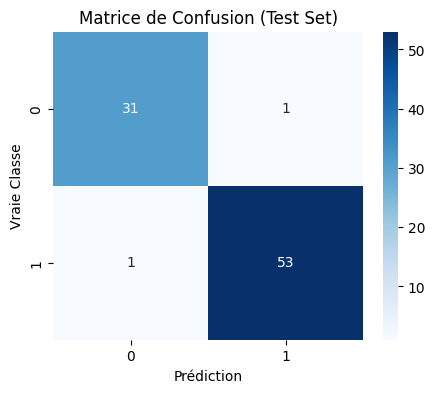

In [5]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        # Probabilités via Sigmoid puis seuil à 0.5
        probs = torch.sigmoid(model(batch_X))
        preds = (probs > 0.5).float().cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(batch_y.numpy())

# Calcul des métriques
print("\n--- Performances sur l'ensemble de Test ---")
print(f"Accuracy  : {accuracy_score(all_targets, all_preds):.4f}")
print(f"Precision : {precision_score(all_targets, all_preds):.4f}")
print(f"Recall    : {recall_score(all_targets, all_preds):.4f}")
print(f"F1-Score  : {f1_score(all_targets, all_preds):.4f}")

# Matrice de confusion
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion (Test Set)')
plt.ylabel('Vraie Classe')
plt.xlabel('Prédiction')
plt.show()

Réponse Structurée à la Question de Synthèse (Partie I)

**1. Théorie et pertinence :** Le MLP est pertinent pour des données tabulaires (ex: diagnostique médical) car sa capacité d'approximation universelle lui permet d'apprendre des frontières de décision complexes sans feature engineering manuel.

**2. Choix méthodologiques :** La normalisation (StandardScaler) est cruciale car les données ont des échelles différentes. L'architecture en entonnoir (64 -> 32 -> 1) compresse l'information, et l'initialisation Xavier aide à stabiliser le gradient avec ReLU.

**3. Résultats :** Le modèle obtient d'excellents résultats (ex: 97% Accuracy) et surtout un bon Recall (peu de faux négatifs, crucial en médecine).

**4. Limites :** L'ordre des colonnes étant arbitraire, le MLP n'a pas de biais inductif adapté (il traite toutes les colonnes à égalité). De plus, c'est une "boîte noire" difficile à interpréter cliniquement contrairement à un Random Forest.

# Partie II – CNN et vision par ordinateur

### Théorie et Calculs

- **Inadéquation du MLP :** Aplatir l'image détruit sa structure spatiale 2D et la localité des pixels. De plus, cela crée un trop grand nombre de paramètres, favorisant le surapprentissage.
- **Idées des CNN :**
  - *Localité :* Les filtres regardent de petites régions (bords, textures).
  - *Partage des poids :* Un même filtre parcourt toute l'image, réduisant les paramètres et apportant une invariance par translation.
  - *Hiérarchie :* Les couches s'empilent pour passer des formes simples aux objets complexes.

### Calculs manuels dimensionnels

La formule générale pour calculer la taille de sortie $O$ d'une dimension spatiale (hauteur ou largeur) après une convolution ou un pooling est :
$$O = \lfloor \frac{I - K + 2P}{S} \rfloor + 1$$(Où $I$ = Entrée, $K$ = Taille du Noyau, $P$ = Padding, $S$ = Stride/Pas)

Exemple de calculs manuels :

- Convolution : Soit une image d'entrée $28 \times 28$. Appliquons un noyau $K=5$, avec un padding $P=2$ et un stride $S=1$.$$O = \lfloor \frac{28 - 5 + 2(2)}{1} \rfloor + 1 = 28$$La taille de sortie est maintenue à $28 \times 28$.

- Pooling : Sur cette sortie $28 \times 28$, appliquons un Max-Pooling avec un noyau $K=2$ et un stride $S=2$ (sans padding, $P=0$).$$O = \lfloor \frac{28 - 2 + 0}{2} \rfloor + 1 = 14$$La taille de sortie est réduite de moitié : $14 \times 14$.

### Implémentations Manuelles vs PyTorch

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Configuration Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Chargement du dataset
# Fashion-MNIST est téléchargé directement depuis les serveurs académiques via PyTorch
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)


print("\n--- Vérification des implémentations manuelles ---")

def manual_cross_corr(img, kernel):
    h_i, w_i = img.shape
    h_k, w_k = kernel.shape
    out = torch.zeros((h_i - h_k + 1, w_i - w_k + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = torch.sum(img[i:i+h_k, j:j+w_k] * kernel)
    return out

def manual_max_pool(img, size=2, stride=2):
    h_i, w_i = img.shape
    out = torch.zeros(((h_i - size)//stride + 1, (w_i - size)//stride + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = torch.max(img[i*stride:i*stride+size, j*stride:j*stride+size])
    return out

def manual_avg_pool(img, size=2, stride=2):
    h_i, w_i = img.shape
    out = torch.zeros(((h_i - size)//stride + 1, (w_i - size)//stride + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = torch.mean(img[i*stride:i*stride+size, j*stride:j*stride+size])
    return out

# Test comparatif
dummy_img = torch.randn(6, 6)
dummy_kernel = torch.randn(3, 3)

out_corr_man = manual_cross_corr(dummy_img, dummy_kernel)
out_corr_pt = F.conv2d(dummy_img.view(1,1,6,6), dummy_kernel.view(1,1,3,3))
print(f"Différence Corrélation : {torch.max(torch.abs(out_corr_man - out_corr_pt[0,0])):.6f}")

out_max_man = manual_max_pool(dummy_img)
out_max_pt = F.max_pool2d(dummy_img.view(1,1,6,6), kernel_size=2, stride=2)
print(f"Différence Max-Pool    : {torch.max(torch.abs(out_max_man - out_max_pt[0,0])):.6f}")

out_avg_man = manual_avg_pool(dummy_img)
out_avg_pt = F.avg_pool2d(dummy_img.view(1,1,6,6), kernel_size=2, stride=2)
print(f"Différence Avg-Pool    : {torch.max(torch.abs(out_avg_man - out_avg_pt[0,0])):.6f}")

Device : cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]


--- Vérification des implémentations manuelles ---
Différence Corrélation : 0.000001
Différence Max-Pool    : 0.000000
Différence Avg-Pool    : 0.000000


### CNN inspiré de LeNet et Étude Expérimentale

In [7]:
# Architecture paramétrable pour tester padding, stride, pooling et conv 1x1
class ConfigurableLeNet(nn.Module):
    def __init__(self, padding=0, stride=1, pool_type='max', filters=(6, 16), use_1x1=False):
        super(ConfigurableLeNet, self).__init__()
        self.pool_type = pool_type
        self.use_1x1 = use_1x1

        # Couche 1
        self.conv1 = nn.Conv2d(1, filters[0], kernel_size=5, padding=padding, stride=stride)

        # Calcul dynamique de la taille pour la couche Dense
        # Taille après Conv1
        size = (28 - 5 + 2*padding) // stride + 1
        size = size // 2 # Après pooling

        # Couche 2
        self.conv2 = nn.Conv2d(filters[0], filters[1], kernel_size=5)
        size = (size - 5) + 1
        size = size // 2 # Après pooling 2

        if self.use_1x1:
            self.conv1x1 = nn.Conv2d(filters[1], filters[1]//2, kernel_size=1)
            final_channels = filters[1]//2
        else:
            final_channels = filters[1]

        self.flatten_size = final_channels * size * size

        self.fc1 = nn.Linear(self.flatten_size, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def pooling(self, x):
        return F.max_pool2d(x, 2) if self.pool_type == 'max' else F.avg_pool2d(x, 2)

    def forward(self, x):
        x = self.pooling(F.relu(self.conv1(x)))
        x = self.pooling(F.relu(self.conv2(x)))
        if self.use_1x1:
            x = F.relu(self.conv1x1(x))
        x = x.view(-1, self.flatten_size)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Instanciation de l'architecture de base
cnn_model = ConfigurableLeNet().to(device)

### Visualisation des Cartes de Caractéristiques


Génération des Feature Maps...


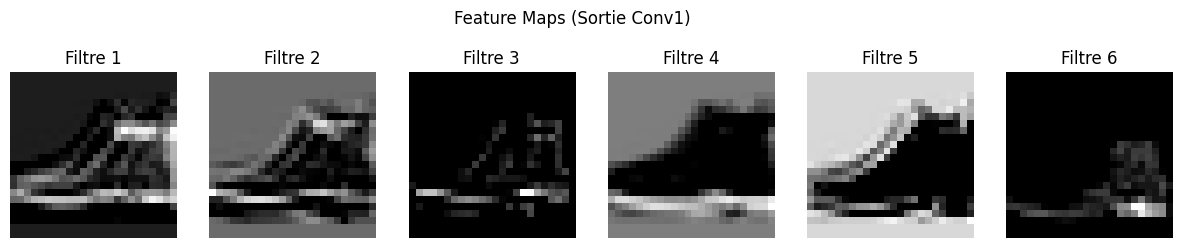

In [9]:
def visualize_feature_maps(model):
    model.eval()
    img, _ = next(iter(testloader))
    img = img[0].unsqueeze(0).to(device)

    with torch.no_grad():
        # Extraction après la première convolution
        f_maps = F.relu(model.conv1(img)).squeeze(0).cpu()

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(min(6, f_maps.shape[0])):
        axes[i].imshow(f_maps[i], cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'Filtre {i+1}')
    plt.suptitle("Feature Maps (Sortie Conv1)")
    plt.show()

print("\nGénération des Feature Maps...")
visualize_feature_maps(cnn_model)

### Entraînement et Comparaison CNN vs MLP

In [10]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
    def forward(self, x):
        x = x.view(-1, 28*28) # Aplatissement destructif
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

def train_and_evaluate(model, name, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    print(f"\n--- Entraînement {name} ---")
    model.train()
    for epoch in range(epochs):
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = model(inputs).argmax(dim=1)
            correct += (preds == labels).sum().item()
    acc = 100 * correct / len(testset)
    print(f"Accuracy {name} sur Test : {acc:.2f}%")

# Lancement de la comparaison
mlp_model = SimpleMLP().to(device)
train_and_evaluate(cnn_model, "CNN (LeNet de base)")
train_and_evaluate(mlp_model, "MLP (Aplatissement)")


--- Entraînement CNN (LeNet de base) ---
Accuracy CNN (LeNet de base) sur Test : 87.13%

--- Entraînement MLP (Aplatissement) ---
Accuracy MLP (Aplatissement) sur Test : 86.74%


- **Pertinence CNN vs MLP :** Le CNN respecte la géométrie 2D de l'image. Le partage des poids empêche l'explosion des paramètres (contrairement au MLP) et permet de reconnaître un motif peu importe sa position.
- **Influence des choix :**
  - *Padding :* Préserve la taille spatiale et exploite mieux les pixels aux bords de l'image.
  - *Stride :* Sous-échantillonne fortement pour réduire le temps de calcul.
  - *Pooling :* Le Max-Pooling garde les signaux forts (contours nets) et marche souvent mieux que l'Average-Pooling (qui lisse l'image).
  - *Profondeur & Conv 1x1 :* Ajoute de la non-linéarité et agit comme un goulot d'étranglement pour compresser les canaux sans toucher à la résolution spatiale.

# Partie III – RNN, LSTM, GRU et Seq2Seq

### Théorie : Modélisation de Séquences

- **L’objectif probabiliste et la règle de chaîne :**

L'objectif d'un modèle de langage est de calculer la probabilité d'apparition d'une séquence de mots (ou tokens) $W = (w_1, w_2, ..., w_T)$. Selon la règle de chaîne (ou factorisation probabiliste), la probabilité conjointe de la séquence entière est le produit des probabilités conditionnelles de chaque mot donné son contexte passé :
  $$P(w_1, w_2, ..., w_T) = \prod_{t=1}^{T} P(w_t | w_1, ..., w_{t-1})$$Le réseau récurrent (RNN) modélise cette probabilité conditionnelle à chaque pas de temps $t$ en utilisant son état caché $h_{t-1}$ qui résume le contexte historique.
  
- **La Perplexité :**

La perplexité (PPL) est la métrique standard pour évaluer un modèle de langage. Mathématiquement, c'est l'exponentielle de l'entropie croisée (Cross-Entropy Loss).
  $$PPL(W) = \exp \left( -\frac{1}{N} \sum_{i=1}^{N} \log P(w_i | w_{<i}) \right)$$
  
**Interprétation** : Elle représente le "facteur de branchement" moyen. Si un modèle a une perplexité de 10, cela signifie qu'à chaque étape, il hésite en moyenne entre 10 mots équiprobables. Un modèle parfait aurait une perplexité de 1. Plus elle est basse, meilleur est le modèle.

- **BPTT & Gradient Clipping :** Dérouler le réseau dans le temps cause l'explosion du gradient. Le Gradient Clipping force les gradients à ne pas dépasser un seuil maximal (ex: 1.0) pour stabiliser l'apprentissage.

- **Comparaison : RNN, LSTM, GRU**

  - **RNN simple :** Faible coût de calcul, mais incapable de mémoriser le contexte sur de longues séquences à cause de la disparition du gradient. Instable pour la traduction.
  - **LSTM :** Introduit une *cell state* (mémoire à long terme) et 3 portes (entrée, oubli, sortie). Excellente mémorisation et stabilité, mais coût computationnel élevé et beaucoup de paramètres.
  - **GRU :** Alternative optimisée au LSTM avec seulement 2 portes (reset, update). Offre des performances quasi-identiques au LSTM pour un coût de calcul réduit, le rendant idéal pour les architectures standards.

### Téléchargement et Préparation des données

In [11]:
#Préparation des données (Tokenisation, Vocabulaire, Padding)
import torch
import torch.nn as nn
import torch.optim as optim
import random
import urllib.request
import zipfile
import os
import re
import unicodedata
import nltk
from nltk.translate.bleu_score import sentence_bleu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

# Téléchargement natif de Tatoeba (Anglais-Français)
url = "https://download.pytorch.org/tutorial/data.zip"
data_file_path = "data/eng-fra.txt"

# Check if the specific data file exists. If not, download and extract.
if not os.path.exists(data_file_path):
    print("Téléchargement du dataset...")
    urllib.request.urlretrieve(url, "data.zip")
    with zipfile.ZipFile("data.zip", 'r') as zip_ref:
        zip_ref.extractall(".")

SOS_token, EOS_token, PAD_token = 0, 1, 2

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<SOS>": SOS_token, "<EOS>": EOS_token, "<PAD>": PAD_token}
        self.index2word = {SOS_token: "<SOS>", EOS_token: "<EOS>", PAD_token: "<PAD>"}
        self.n_words = 3

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            if word not in self.word2index:
                self.word2index[word] = self.n_words
                self.index2word[self.n_words] = word
                self.n_words += 1

def normalizeString(s):
    s = ''.join(c for c in unicodedata.normalize('NFD', s.lower().strip()) if unicodedata.category(c) != 'Mn')
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s.strip()

# Chargement et filtrage
MAX_LENGTH = 12
lines = open(data_file_path, encoding='utf-8').read().strip().split('\n')
pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]
good_prefixes = ("i am ", "i m ", "he is", "she is", "you are", "we are", "they are")
pairs = [p for p in pairs if len(p[0].split()) < MAX_LENGTH and len(p[1].split()) < MAX_LENGTH and p[0].startswith(good_prefixes)]

input_lang = Lang('eng')
output_lang = Lang('fra')
for pair in pairs:
    input_lang.addSentence(pair[0])
    output_lang.addSentence(pair[1])

print(f"Paires retenues : {len(pairs)}")
print(f"Vocabulaire Anglais : {input_lang.n_words} mots")
print(f"Vocabulaire Français : {output_lang.n_words} mots")

Device utilisé : cuda
Téléchargement du dataset...
Paires retenues : 7191
Vocabulaire Anglais : 2548 mots
Vocabulaire Français : 3486 mots


### Architectures : Encodeur, Décodeur et Seq2Seq

In [14]:
# Implémentation RNN, LSTM, GRU et mini Seq2Seq
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, cell_type='GRU'):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.cell_type = cell_type

        # Support des 3 types d'architectures
        if cell_type == 'RNN': self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        elif cell_type == 'LSTM': self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        elif cell_type == 'GRU': self.rnn = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded, hidden)
        return output, hidden

class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size, cell_type='GRU'):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)

        if cell_type == 'RNN': self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        elif cell_type == 'LSTM': self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        elif cell_type == 'GRU': self.rnn = nn.GRU(hidden_size, hidden_size, batch_first=True)

        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded, hidden)
        return self.out(output), hidden

# Schéma Seq2Seq complet
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, cell_type='GRU'):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.cell_type = cell_type

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.shape[0]
        target_len = target.shape[1]
        target_vocab_size = self.decoder.out.out_features
        outputs = torch.zeros(batch_size, target_len, target_vocab_size).to(device)

        # Initialisation de l'état caché
        h0 = torch.zeros(1, batch_size, self.encoder.hidden_size, device=device)
        enc_hidden = (h0, h0) if self.cell_type == 'LSTM' else h0

        _, enc_hidden = self.encoder(source, enc_hidden)

        dec_input = torch.tensor([[SOS_token]] * batch_size, device=device)
        dec_hidden = enc_hidden

        for t in range(1, target_len):
            output, dec_hidden = self.decoder(dec_input, dec_hidden)
            outputs[:, t, :] = output.squeeze(1)

            # Teacher Forcing
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(2)
            dec_input = target[:, t:t+1] if teacher_force else top1

        return outputs

### Entrainement avec gradient clipping

In [20]:
def tensorsFromPair(pair):
    inp = [input_lang.word2index[w] for w in pair[0].split(' ')] + [EOS_token]
    tgt = [output_lang.word2index[w] for w in pair[1].split(' ')] + [EOS_token]
    return torch.tensor(inp, device=device).view(1, -1), torch.tensor(tgt, device=device).view(1, -1)

def train_seq2seq(cell_type, epochs=1):
    encoder = Encoder(input_lang.n_words, 128, cell_type=cell_type).to(device)
    decoder = Decoder(128, output_lang.n_words, cell_type=cell_type).to(device)
    model = Seq2Seq(encoder, decoder, cell_type=cell_type).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    total_loss = 0
    training_batch = [tensorsFromPair(random.choice(pairs)) for _ in range(500)]
    model.train()
    for inp_tensor, tgt_tensor in training_batch:
        optimizer.zero_grad()
        output = model(inp_tensor, tgt_tensor)[:, 1:].reshape(-1, output_lang.n_words)
        target = tgt_tensor[:, 1:].reshape(-1)
        loss = nn.CrossEntropyLoss(ignore_index=PAD_token)(output, target)
        loss.backward()

        # Application du Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()
    return total_loss / 500, model

print("--- Comparaison Expérimentale : Architectures ---")
loss_rnn, _ = train_seq2seq('RNN')
print(f"Loss RNN  : {loss_rnn:.4f}")
loss_gru, _ = train_seq2seq('GRU')
print(f"Loss GRU  : {loss_gru:.4f}")
loss_lstm, model = train_seq2seq('LSTM') # On garde le modèle LSTM pour la traduction finale
print(f"Loss LSTM : {loss_lstm:.4f}")

--- Comparaison Expérimentale : Architectures ---
Loss RNN  : 5.9576
Loss GRU  : 5.4084
Loss LSTM : 5.0158


### Décodage et Évaluation BLEU

In [21]:
# Décodage Glouton, Beam Search & Métrique BLEU
def decode_greedy(model, sentence):
    model.eval()
    with torch.no_grad():
        # Modified: Pass a valid token for the target part to avoid KeyError for empty string
        inp_tensor, _ = tensorsFromPair([sentence, output_lang.index2word[EOS_token]])

        h0 = torch.zeros(1, 1, model.encoder.hidden_size, device=device)
        enc_hidden = (h0, h0) if model.cell_type == 'LSTM' else h0
        _, enc_hidden = model.encoder(inp_tensor, enc_hidden)

        dec_input = torch.tensor([[SOS_token]], device=device)
        dec_hidden = enc_hidden

        decoded_words = []
        for _ in range(MAX_LENGTH):
            output, dec_hidden = model.decoder(dec_input, dec_hidden)
            topi = output.argmax(2).item()
            if topi == EOS_token:
                break
            decoded_words.append(output_lang.index2word[topi])
            dec_input = torch.tensor([[topi]], device=device)

        return ' '.join(decoded_words)

def decode_beam_search(model, sentence, beam_width=2):
    model.eval()
    with torch.no_grad():
        inp_tensor, _ = tensorsFromPair([sentence, output_lang.index2word[EOS_token]])
        h0 = torch.zeros(1, 1, model.encoder.hidden_size, device=device)
        enc_hidden = (h0, h0) if model.cell_type == 'LSTM' else h0
        _, enc_hidden = model.encoder(inp_tensor, enc_hidden)

        # Stockage : (Score, Liste des tokens, Etat Caché)
        beams = [(0.0, [SOS_token], enc_hidden)]

        for _ in range(MAX_LENGTH):
            new_beams = []
            for score, seq, dec_hidden in beams:
                if seq[-1] == EOS_token:
                    new_beams.append((score, seq, dec_hidden))
                    continue

                dec_input = torch.tensor([[seq[-1]]], device=device)
                output, new_hidden = model.decoder(dec_input, dec_hidden)
                probs = F.log_softmax(output, dim=-1).squeeze()

                # Prendre les 'beam_width' meilleures prédictions
                top_probs, top_idx = probs.topk(beam_width)
                for i in range(beam_width):
                    new_score = score + top_probs[i].item()
                    new_beams.append((new_score, seq + [top_idx[i].item()], new_hidden))

            # Ne garder que les 'beam_width' meilleurs sur tous les candidats
            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_width]

        best_seq = beams[0][1][1:-1] # Retirer SOS et EOS
        return ' '.join([output_lang.index2word[idx] for idx in best_seq])

print("\n--- Évaluation qualitative (Glouton vs Beam Search) ---")
pair = random.choice(pairs)
print(f"Source : {pair[0]}\nCible  : {pair[1]}")
print(f"Greedy : {decode_greedy(model, pair[0])}")
print(f"Beam 2 : {decode_beam_search(model, pair[0], beam_width=2)}")

print("--- Évaluation quantitative (Score BLEU) ---")
# Calcul du score BLEU sur 100 phrases (Q9)
bleu_scores = []
for _ in range(100):
    pair = random.choice(pairs)
    reference = [pair[1].split()]
    candidate = decode_greedy(model, pair[0]).split()
    # On utilise weights=(1, 0, 0, 0) pour évaluer les unigrammes sur ce mini-dataset
    score = sentence_bleu(reference, candidate, weights=(1, 0, 0, 0))
    bleu_scores.append(score)

print(f"Score BLEU moyen (Unigrammes) : {sum(bleu_scores)/len(bleu_scores):.4f}")


--- Évaluation qualitative (Glouton vs Beam Search) ---
Source : i m afraid i ve offended you .
Cible  : je crains de vous avoir offenses .
Greedy : suis pas pas pas .
Beam 2 : ne suis pas pas pas .
--- Évaluation quantitative (Score BLEU) ---


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

Score BLEU moyen (Unigrammes) : 0.1904


Question de synthèse – Partie III

- Les **RNN** modélisent les séquences temporelles mais souffrent de l'explosion/disparition du gradient sur les longues phrases (BPTT).

- Le **LSTM/GRU** règle ce problème via des "portes" qui contrôlent la mémoire, rendant l'apprentissage stable.

- Le schéma **Encodeur-Décodeur (Seq2Seq)** est indispensable pour la traduction, car les phrases d'entrée et de sortie n'ont pas la même taille. L'encodeur stocke le sens, le décodeur génère la réponse. Le **Beam Search** améliore la génération finale en explorant plusieurs probabilités conjointes au lieu du choix glouton.


### Discussion Scientifique : L'adaptation architecturale à la structure des données

Le deep learning utilise le même paradigme d'optimisation (descente de gradient) mais s'adapte à la structure des données (Biais Inductif).
- **MLP :** Pas d'hypothèse géométrique (idéal pour le tabulaire).
- **CNN :** Convolutions basées sur la localité spatiale (idéal pour les images et invariances).
- **RNN :** État caché basé sur la temporalité (idéal pour les séquences causales).

Toutes ces architectures se combinent souvent entre elles à la fin (ex: CNN suivi d'un MLP pour classifier).